In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots 
import numpy as np

plt.style.use(["science","notebook", "grid"])

from funciones import unir_pwouts_en_trayectoria

from ase.visualize import view
from ase.io import read, write

In [20]:
import re
import glob
import numpy as np
import csv
import os

# ========== REGEX PARA TEMPERATURA Y ENERGÍA CINÉTICA ==========
re_Temp = re.compile(r'temperature\s*=\s*([0-9.Ee+-]+)\s*K', re.IGNORECASE)
re_Ekin = re.compile(r'kinetic energy.*?=\s*([0-9.Ee+-]+)\s*(Ry|eV)', re.IGNORECASE)

RY_TO_EV = 13.605693009  # conversión estándar


def parse_md_output(filename):
    """Extrae listas de temperaturas y energías cinéticas (en eV) de un archivo pw.x."""
    temps = []
    ekins = []

    with open(filename, 'r') as f:
        for line in f:
            # temperatura
            mT = re_Temp.search(line)
            if mT:
                temps.append(float(mT.group(1)))

            # energía cinética
            mE = re_Ekin.search(line)
            if mE:
                value = float(mE.group(1))
                unit = mE.group(2).lower()

                if unit == "ry":
                    value *= RY_TO_EV

                ekins.append(value)

    return temps, ekins


# ========== DIRECTORIOS ==========
folders = ["outputs_1", "outputs_2"]

# datos: folder → archivo → (temps, ekins)
all_data = {}

for folder in folders:
    if not os.path.isdir(folder):
        print(f"⚠️ Carpeta no encontrada: {folder}")
        continue

    print(f"\n=== Leyendo carpeta: {folder} ===")
    files = sorted(glob.glob(os.path.join(folder, "pw.out.*")))

    all_data[folder] = {}

    for fname in files:
        temps, ekins = parse_md_output(fname)

        if len(temps) != len(ekins):
            print(f"⚠️ ADVERTENCIA: {fname} tiene {len(temps)} temperaturas y {len(ekins)} energías cinéticas.")

        all_data[folder][fname] = (temps, ekins)

        print(f"  {os.path.basename(fname)}: {len(temps)} iteraciones")


# ========== CSV FINAL ==========
output_csv = "temperaturas_ekin_completo.csv"
with open(output_csv, "w", newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["folder", "archivo", "iteracion", "temperatura_K", "energia_cinetica_eV"])

    for folder, files in all_data.items():
        for fname, (temps, ekins) in files.items():
            base = os.path.basename(fname)
            n_iters = min(len(temps), len(ekins))

            for i in range(n_iters):
                writer.writerow([folder, base, i, temps[i], ekins[i]])

print(f"\nCSV generado: {output_csv}")



=== Leyendo carpeta: outputs_1 ===
⚠️ ADVERTENCIA: outputs_1/pw.out.27896 tiene 218 temperaturas y 217 energías cinéticas.
  pw.out.27896: 218 iteraciones
  pw.out.27972: 179 iteraciones
  pw.out.28006: 230 iteraciones
  pw.out.28046: 203 iteraciones
  pw.out.28099: 171 iteraciones

=== Leyendo carpeta: outputs_2 ===
⚠️ ADVERTENCIA: outputs_2/pw.out.28895 tiene 183 temperaturas y 182 energías cinéticas.
  pw.out.28895: 183 iteraciones
  pw.out.28984: 185 iteraciones
  pw.out.29046: 171 iteraciones
  pw.out.29139: 180 iteraciones
  pw.out.29374: 188 iteraciones
  pw.out.29624: 187 iteraciones
  pw.out.29799: 197 iteraciones
  pw.out.29937: 198 iteraciones
  pw.out.30033: 202 iteraciones
  pw.out.30117: 211 iteraciones

CSV generado: temperaturas_ekin_completo.csv


In [24]:
import pandas as pd

df_temp = pd.read_csv("/home/hernan-barquero/Desktop/Codigos/PhiS/Computational_Material_Science/carbon_nanoscrolls/t10_interface_corrected/temperaturas_ekin_completo.csv")
df_temp

,folder,archivo,iteracion,temperatura_K,energia_cinetica_eV
0,outputs_1,pw.out.27896,0,300.000000,19.508771
1,outputs_1,pw.out.27896,1,289.686365,152.622819
2,outputs_1,pw.out.27896,2,2266.301069,81.670713
3,outputs_1,pw.out.27896,3,1212.731006,34.472677
4,outputs_1,pw.out.27896,4,511.885870,58.618226
...,...,...,...,...,...
2896,outputs_2,pw.out.30117,206,278.703909,18.769164
2897,outputs_2,pw.out.30117,207,305.159170,20.550779
2898,outputs_2,pw.out.30117,208,289.527959,19.498104
2899,outputs_2,pw.out.30117,209,302.353659,20.361844


In [21]:
prueba = read("outputs_2/pw.out.28984",':')
prueba[0].get_temperature()

0.0

In [ ]:
unir_pwouts_en_trayectoria()

Carpetas detectadas: ['outputs_1', 'outputs_2']


Procesando carpeta: outputs_1 (5 archivos encontrados)
   outputs_1/pw.out.27896: 217 frames añadidos
   outputs_1/pw.out.27972: 178 frames añadidos
   outputs_1/pw.out.28006: 229 frames añadidos
   outputs_1/pw.out.28046: 202 frames añadidos
   outputs_1/pw.out.28099: 170 frames añadidos

Procesando carpeta: outputs_2 (10 archivos encontrados)
   outputs_2/pw.out.28895: 181 frames añadidos
   outputs_2/pw.out.28984: 184 frames añadidos
   outputs_2/pw.out.29046: 170 frames añadidos
   outputs_2/pw.out.29139: 179 frames añadidos
   outputs_2/pw.out.29374: 187 frames añadidos
   outputs_2/pw.out.29624: 186 frames añadidos
   outputs_2/pw.out.29799: 196 frames añadidos
   outputs_2/pw.out.29937: 197 frames añadidos
   outputs_2/pw.out.30033: 201 frames añadidos
   outputs_2/pw.out.30117: 210 frames añadidos

Trayectoria final con 2887 frames guardada en 'trayectoria_continua.traj'


[Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointDFTCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell

In [ ]:
md = read('trayectoria_continua.traj', ':')
md

[Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.999999818359232, 24.999999818359232, 16.799999877937406], calculator=SinglePointCalculator(...)),
 Atoms(symbols='C294H187Al13Cl56N34', pbc=True, cell=[24.9999998183592

In [ ]:
display(md[-1].get_potential_energy(),
		md[-1].get_kinetic_energy(),
		md[-1].get_total_energy())

-157228.11678774326

0.0

-157228.11678774326

In [ ]:
md[1].get_temperature()

0.0

In [ ]:
energies = np.zeros(len(md))
for i in range(len(md)):
	energies[i] = md[i].get_potential_energy()

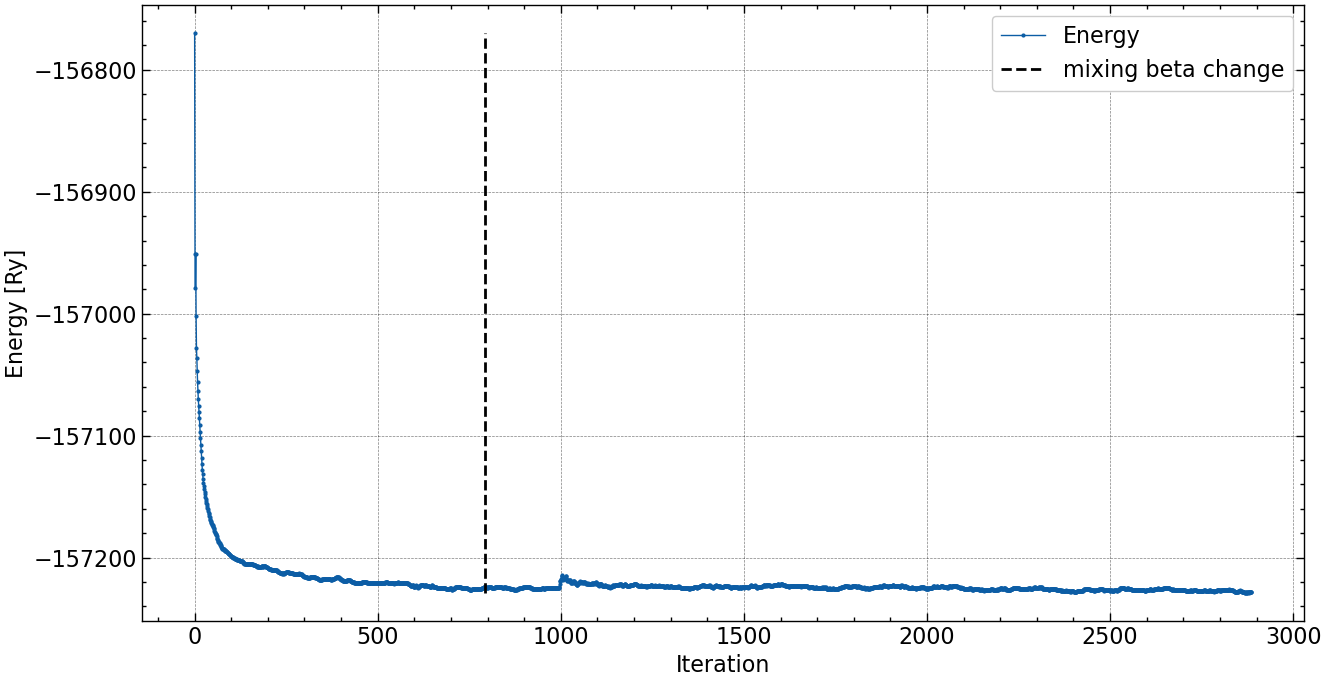

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms = 2, linewidth = 1, label = 'Energy')
ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia.png")

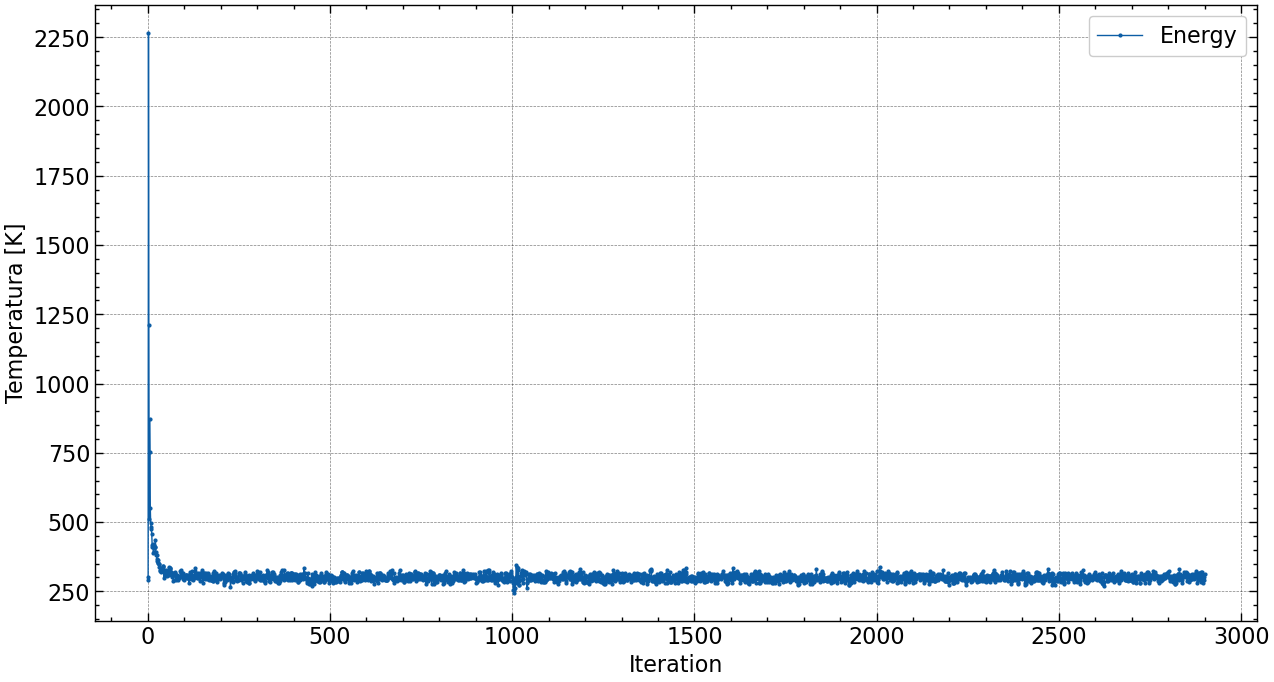

In [27]:
fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(df_temp['temperatura_K'], 'o-', ms = 2, linewidth = 1, label = 'Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies), label ="mixing beta change", color = 'black', linestyles='--')
ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura.png")

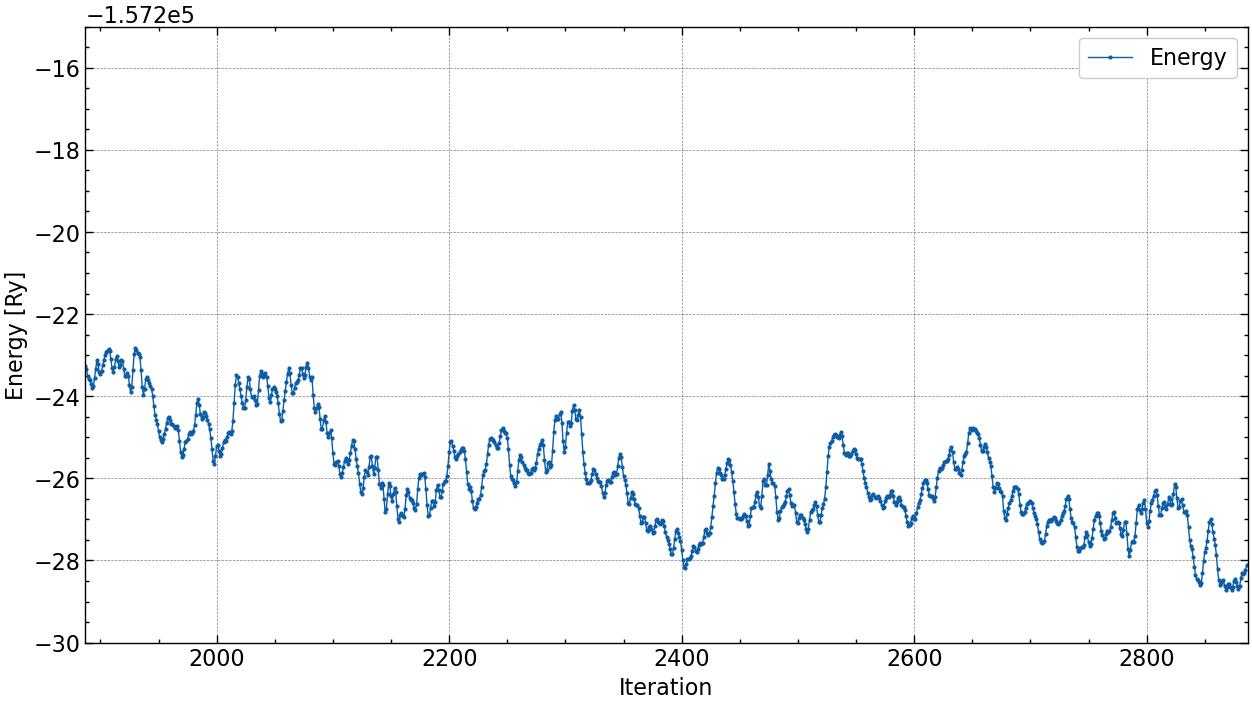

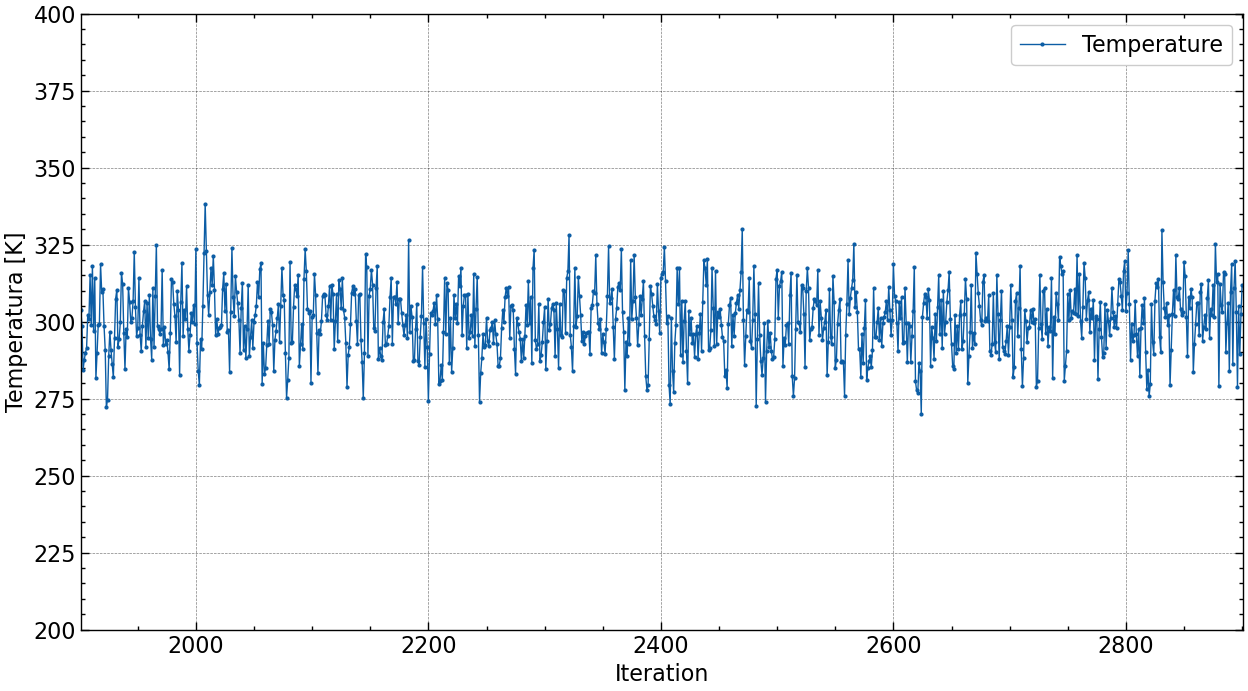

In [39]:
# === PRIMERA GRAFICA: Energía ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(energies, 'o-', ms=2, linewidth=1, label='Energy')
#ax.vlines(x=794, ymax=np.max(energies), ymin=np.min(energies),label="mixing beta change", color='black', linestyles='--')

# ZOOM en las ultimas 1000 iteraciones
N = len(energies)
ax.set_xlim(max(0, N-1000), N)
ax.set_ylim(ymax=-157215, ymin= -157230)

ax.set_ylabel("Energy [Ry]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("energia_zoom.png")


# === SEGUNDA GRAFICA: Temperatura ===

fig, ax = plt.subplots(1,1, figsize=(15,8))
ax.plot(df_temp['temperatura_K'], 'o-', ms=2, linewidth=1, label='Temperature')

# ZOOM en las ultimas 1000 iteraciones
N2 = len(df_temp['temperatura_K'])
ax.set_xlim(max(0, N2-1000), N2)
ax.set_ylim(200,400)

ax.set_ylabel("Temperatura [K]")
ax.set_xlabel("Iteration")
ax.legend()
fig.savefig("temperatura_zoom.png")
